# **프로젝트 주제 : 비트코인 트레이딩 환경에서 강화학습 알고리즘 성능 비교**

In [1]:
!pip install yfinance gymnasium torch matplotlib -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import pickle, os, random
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# Google Drive 마운트 (모델/결과 저장)
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/RL_Project/'
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', device)
print('저장 경로:', SAVE_DIR)

Mounted at /content/drive
Device : cpu
저장 경로: /content/drive/MyDrive/RL_Project/


# **데이터수집 및 전처리**

In [3]:
# 비트코인 데이터 수집 (2020.01.01 ~ 2026.05.31)
def download_btc_data(start='2020-01-01', end='2026-05-31'):
    print('BTC 데이터 다운로드 중...')
    df = yf.download(
        'BTC-USD',
        start=start,
        end=end,
        auto_adjust=True
    )

    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    df.dropna(inplace=True)

    df.columns = [
        'open',
        'high',
        'low',
        'close',
        'volume'
    ]

    print(
        f'수집 완료: {len(df)}일 '
        f'({df.index[0].date()} ~ {df.index[-1].date()})'
    )

    return df


def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()

    rs = avg_gain / (avg_loss + 1e-9)

    return 100 - (100 / (1 + rs))


def add_features(df):
    df = df.copy()

    df['ma5'] = df['close'].rolling(5).mean()
    df['ma20'] = df['close'].rolling(20).mean()

    df['rsi'] = compute_rsi(df['close'], 14)

    df['price_change'] = df['close'].pct_change()
    df['volume_change'] = df['volume'].pct_change()

    df['ma_ratio'] = df['ma5'] / (df['ma20'] + 1e-9)

    df.dropna(inplace=True)

    df.reset_index(drop=False, inplace=True)

    return df

# 데이터 생성
df_raw = download_btc_data(
    start='2020-01-01',
    end='2026-05-31'
)

df = add_features(df_raw)

# 시간 기준 분할
# Train : 2020-01-01 ~ 2024-12-31
# Test  : 2025-01-01 ~ 2026-05-31
train_end_date = '2024-12-31'

df_train = (
    df[df['Date'] <= train_end_date]
    .reset_index(drop=True)
)

df_test = (
    df[df['Date'] > train_end_date]
    .reset_index(drop=True)
)

split_idx = len(df_train)

print("\n===== Dataset Split =====")
print(
    f"Train : {df_train['Date'].min().date()} "
    f"~ {df_train['Date'].max().date()}"
)
print(
    f"Test  : {df_test['Date'].min().date()} "
    f"~ {df_test['Date'].max().date()}"
)

print(f"Train Samples : {len(df_train):,}")
print(f"Test Samples  : {len(df_test):,}")
print(
    f"Train Ratio   : "
    f"{len(df_train)/len(df)*100:.1f}%"
)
print(
    f"Test Ratio    : "
    f"{len(df_test)/len(df)*100:.1f}%"
)

BTC 데이터 다운로드 중...


[*********************100%***********************]  1 of 1 completed

수집 완료: 2342일 (2020-01-01 ~ 2026-05-30)

===== Dataset Split =====
Train : 2020-01-20 ~ 2024-12-31
Test  : 2025-01-01 ~ 2026-05-30
Train Samples : 1,808
Test Samples  : 515
Train Ratio   : 77.8%
Test Ratio    : 22.2%


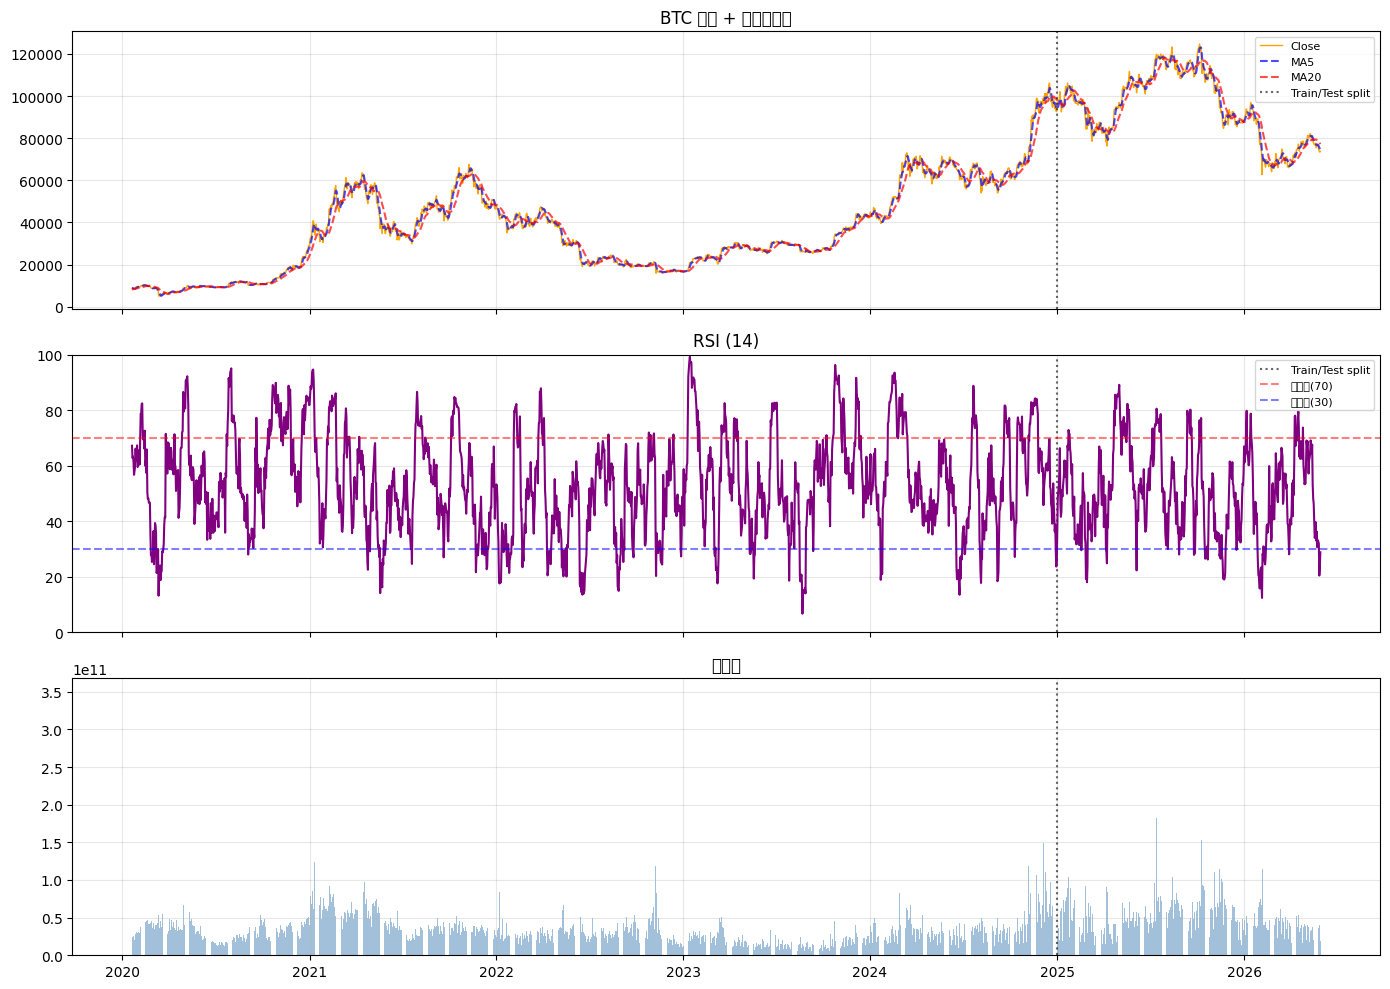

In [4]:
# 데이터 시각화
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df['Date'], df['close'], color='orange', linewidth=1, label='Close')
axes[0].plot(df['Date'], df['ma5'],  color='blue',   linestyle='--', alpha=0.7, label='MA5')
axes[0].plot(df['Date'], df['ma20'], color='red',    linestyle='--', alpha=0.7, label='MA20')
split_date = df['Date'].iloc[split_idx]
for ax in axes:
    ax.axvline(split_date, color='black', linestyle=':', alpha=0.6, label='Train/Test split')
axes[0].set_title('BTC 종가 + 이동평균선')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(df['Date'], df['rsi'], color='purple')
axes[1].axhline(70, color='red',  linestyle='--', alpha=0.5, label='과매수(70)')
axes[1].axhline(30, color='blue', linestyle='--', alpha=0.5, label='과매도(30)')
axes[1].set_title('RSI (14)')
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

axes[2].bar(df['Date'], df['volume'], color='steelblue', alpha=0.5)
axes[2].set_title('거래량')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig1_data_overview.png', dpi=150)
plt.show()

# **환경구현**

*   MDP 설계

1.   State (5차원): [ma_ratio-1, rsi/100, price_change, volume_change, position]
2. Action: 0 = Hold / 1 = Buy / 2 = Sell
3. Reward : 매도 시 실현수익률 지급 / 보유 중 매 스텝 미실현 손익(×0.1) 소규모 반영 / 잘못된 행동 시 -0.001 페널티
4. Transition : 행동 수행 후 다음 거래일로 이동 / 1거래일 = 1 step
5. Terminal : 데이터의 마지막 거래일에 도달하면 Episode 종료

> **수정** Reward에 보유 중 미실현 손익을 스텝마다 소규모 반영 → REINFORCE의 Hold 수렴 문제 완화

In [5]:
class BTCTradingEnv(gym.Env):
    metadata = {'render_modes': []}

    def __init__(self, df, initial_balance=10000.0, transaction_fee=0.001,
                 unrealized_scale=0.1):
        super().__init__()
        self.df               = df.reset_index(drop=True)
        self.n_steps          = len(df)
        self.initial_balance  = initial_balance
        self.transaction_fee  = transaction_fee
        self.unrealized_scale = unrealized_scale  # 미실현 손익 반영 비율
        self.action_space     = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low  = np.array([-5.0, 0.0, -1.0, -10.0, 0.0], dtype=np.float32),
            high = np.array([ 5.0, 1.0,  1.0,  10.0, 1.0], dtype=np.float32)
        )

    def _get_obs(self):
        row = self.df.iloc[self.current_step]
        return np.array([
            np.clip(row['ma_ratio'] - 1.0, -5.0, 5.0),
            row['rsi'] / 100.0,
            np.clip(row['price_change'], -1.0, 1.0),
            np.clip(row['volume_change'], -10.0, 10.0),
            float(self.position),
        ], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step  = 0
        self.balance       = self.initial_balance
        self.position      = 0
        self.buy_price     = 0.0
        self.total_profit  = 0.0
        self.trade_log     = []
        self.prev_price    = self.df.iloc[0]['close']
        return self._get_obs(), {}

    def step(self, action):
        current_price = self.df.iloc[self.current_step]['close']
        reward = 0.0

        if action == 1:   # Buy
            if self.position == 0:
                self.position  = 1
                self.buy_price = current_price * (1 + self.transaction_fee)
            else:
                reward = -0.001
        elif action == 2: # Sell
            if self.position == 1:
                sell_price  = current_price * (1 - self.transaction_fee)
                profit_rate = (sell_price - self.buy_price) / self.buy_price
                reward      = profit_rate
                self.total_profit += profit_rate
                self.trade_log.append({
                    'step': self.current_step,
                    'buy_price': self.buy_price,
                    'sell_price': sell_price,
                    'profit_rate': profit_rate
                })
                self.position  = 0
                self.buy_price = 0.0
            else:
                reward = -0.001

        # [수정 ①] 보유 중 미실현 손익을 스텝 reward에 소규모 반영
        if self.position == 1:
            price_change = (current_price - self.prev_price) / (self.prev_price + 1e-9)
            reward += price_change * self.unrealized_scale

        self.prev_price   = current_price
        self.current_step += 1
        terminated = self.current_step >= self.n_steps - 1
        obs  = self._get_obs() if not terminated else np.zeros(5, dtype=np.float32)
        info = {'step': self.current_step, 'price': current_price,
                'position': self.position, 'total_profit': self.total_profit}
        return obs, reward, terminated, False, info

    def get_buy_and_hold_return(self):
        return (self.df.iloc[-1]['close'] - self.df.iloc[0]['close']) / self.df.iloc[0]['close']

print('BTCTradingEnv 정의 완료 (미실현 손익 reward 추가)')
print(f'  State dim : {BTCTradingEnv(df_train).observation_space.shape[0]}')
print(f'  Action dim: {BTCTradingEnv(df_train).action_space.n}')

BTCTradingEnv 정의 완료 (미실현 손익 reward 추가)
  State dim : 5
  Action dim: 3


# **REINFORCE**

1. 알고리즘 : Monte Carlo Policy Gradient  
2. 업데이트 : 에피소드 종료 후 $\nabla_\theta J = \sum_t G_t \nabla_\theta \log\pi_\theta(a_t|s_t)$
3. **수정** 엔트로피 정규화 추가 → Hold 과수렴 방지

In [6]:
# ---- Policy Network ----
class PolicyNetwork(nn.Module):
    """State -> Action 확률 분포 (MLP)"""
    def __init__(self, state_dim=5, action_dim=3, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )
    def forward(self, x):
        return torch.softmax(self.net(x), dim=-1)

# ---- REINFORCE Agent ----
class REINFORCEAgent:
    def __init__(self, state_dim=5, action_dim=3, hidden_dim=64,
                 lr=1e-3, gamma=0.99, entropy_coef=0.01):
        self.gamma        = gamma
        self.entropy_coef = entropy_coef  # [수정 ②] 엔트로피 계수
        self.policy       = PolicyNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.optimizer    = optim.Adam(self.policy.parameters(), lr=lr)
        self.log_probs    = []
        self.entropies    = []
        self.rewards      = []

    def select_action(self, state):
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        probs   = self.policy(state_t)
        dist    = Categorical(probs)
        action  = dist.sample()
        self.log_probs.append(dist.log_prob(action))
        self.entropies.append(dist.entropy())  # [수정 ②] 엔트로피 저장
        return action.item()

    def store_reward(self, reward):
        self.rewards.append(reward)

    def compute_returns(self):
        G, returns = 0.0, []
        for r in reversed(self.rewards):
            G = r + self.gamma * G
            returns.insert(0, G)
        returns = torch.tensor(returns, dtype=torch.float32).to(device)
        if returns.std() > 1e-8:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        return returns

    def update(self):
        returns      = self.compute_returns()
        log_probs_t  = torch.stack(self.log_probs)
        entropies_t  = torch.stack(self.entropies)
        pg_loss      = -(log_probs_t * returns).mean()
        entropy_loss = -entropies_t.mean()  # [수정 ②] 엔트로피 보너스 (음수 → 다양성 장려)
        loss         = pg_loss + self.entropy_coef * entropy_loss
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy.parameters(), max_norm=1.0)
        self.optimizer.step()
        self.log_probs, self.entropies, self.rewards = [], [], []
        return loss.item()

    def save(self, path):
        torch.save(self.policy.state_dict(), path)

    def load(self, path):
        self.policy.load_state_dict(torch.load(path, map_location=device))

print('REINFORCE 정의 완료 (엔트로피 정규화 추가)')

REINFORCE 정의 완료 (엔트로피 정규화 추가)


In [7]:
def train_reinforce(df_train, n_episodes=300, lr=1e-3, gamma=0.99,
                    seed=0, verbose_interval=50):
    torch.manual_seed(seed)
    np.random.seed(seed)
    env    = BTCTradingEnv(df_train)
    agent  = REINFORCEAgent(lr=lr, gamma=gamma)
    reward_history, profit_history, loss_history = [], [], []

    for ep in range(1, n_episodes + 1):
        obs, _ = env.reset(seed=seed + ep)
        done, ep_reward = False, 0.0
        while not done:
            action = agent.select_action(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            agent.store_reward(reward)
            ep_reward += reward
            done = terminated or truncated
        loss = agent.update()
        reward_history.append(ep_reward)
        profit_history.append(info['total_profit'])
        loss_history.append(loss)
        if ep % verbose_interval == 0:
            print(f'  [Seed {seed}] Ep {ep:4d} | Reward: {ep_reward:7.4f} | '
                  f'Profit: {info["total_profit"]*100:6.2f}% | Loss: {loss:.4f}')
    return agent, reward_history, profit_history, loss_history

# 학습 실행
N_EPISODES = 300
SEEDS      = [0, 1, 2]
RF_LR      = 1e-3
GAMMA      = 0.99

reinforce_results = {}
for seed in SEEDS:
    print(f'\n=== REINFORCE 학습 (seed={seed}) ===')
    agent, rewards, profits, losses = train_reinforce(
        df_train, n_episodes=N_EPISODES, lr=RF_LR, gamma=GAMMA, seed=seed)
    reinforce_results[seed] = (agent, rewards, profits, losses)
    agent.save(SAVE_DIR + f'reinforce_seed{seed}.pth')

print('\nREINFORCE 학습 완료!')


=== REINFORCE 학습 (seed=0) ===
  [Seed 0] Ep   50 | Reward: -0.6680 | Profit: -13.70% | Loss: -0.0110
  [Seed 0] Ep  100 | Reward:  0.1280 | Profit:  62.80% | Loss: -0.0110
  [Seed 0] Ep  150 | Reward:  1.0150 | Profit: 142.77% | Loss: -0.0110
  [Seed 0] Ep  200 | Reward: -0.9254 | Profit: -48.98% | Loss: -0.0110
  [Seed 0] Ep  250 | Reward:  1.8569 | Profit: 216.92% | Loss: -0.0110
  [Seed 0] Ep  300 | Reward:  0.4019 | Profit:  89.36% | Loss: -0.0110

=== REINFORCE 학습 (seed=1) ===
  [Seed 1] Ep   50 | Reward:  0.6139 | Profit: 120.51% | Loss: -0.0110
  [Seed 1] Ep  100 | Reward:  1.3033 | Profit: 181.53% | Loss: -0.0110
  [Seed 1] Ep  150 | Reward:  0.7669 | Profit: 119.78% | Loss: -0.0110
  [Seed 1] Ep  200 | Reward:  0.9194 | Profit: 115.52% | Loss: -0.0110
  [Seed 1] Ep  250 | Reward:  0.5900 | Profit: 104.05% | Loss: -0.0110
  [Seed 1] Ep  300 | Reward:  1.2708 | Profit: 170.51% | Loss: -0.0110

=== REINFORCE 학습 (seed=2) ===
  [Seed 2] Ep   50 | Reward:  0.0775 | Profit:  45.94% 

# **DQN**

1. 알고리즘 : Deep Q-Network  
2. 핵심 요소 : Replay Buffer + Target Network + ε-greedy  
3. 업데이트 : $L = \text{MSE}(Q(s,a),\ r + \gamma \max_{a'} Q_{\text{target}}(s', a'))$
4. **수정** ε decay를 스텝 단위 → 에피소드 단위로 변경 → 탐색 구간 정상화

In [8]:
# Replay Buffer
class ReplayBuffer:
    """경험 (s,a,r,s',done) 저장 및 랜덤 샘플링"""
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch  = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = zip(*batch)
        return (
            torch.FloatTensor(np.array(s)).to(device),
            torch.LongTensor(a).to(device),
            torch.FloatTensor(r).to(device),
            torch.FloatTensor(np.array(ns)).to(device),
            torch.FloatTensor(d).to(device)
        )

    def __len__(self):
        return len(self.buffer)

# Q-Network
class QNetwork(nn.Module):
    """State -> Q값 (action별)"""
    def __init__(self, state_dim=5, action_dim=3, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )
    def forward(self, x):
        return self.net(x)

# DQN Agent
class DQNAgent:
    def __init__(self, state_dim=5, action_dim=3, hidden_dim=64,
                 lr=1e-3, gamma=0.99, buffer_size=10000, batch_size=64,
                 target_update_freq=10,
                 eps_start=1.0, eps_end=0.05, n_episodes=300):
        self.action_dim         = action_dim
        self.gamma              = gamma
        self.batch_size         = batch_size
        self.target_update_freq = target_update_freq
        self.epsilon    = eps_start
        self.eps_start  = eps_start
        self.eps_end    = eps_end
        self.n_episodes = n_episodes  # [수정 ③] 에피소드 총수 저장

        self.q_net      = QNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()
        self.optimizer    = optim.Adam(self.q_net.parameters(), lr=lr)
        self.buffer       = ReplayBuffer(capacity=buffer_size)
        self.update_count = 0

    def select_action(self, state, training=True):
        if training and random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            return self.q_net(state_t).argmax(dim=-1).item()

    def decay_epsilon(self, episode):
        # [수정 ③] 스텝 단위 → 에피소드 단위 선형 감소
        # 전반부 50%: 탐색(1.0→0.05), 후반부 50%: 활용(0.05 유지)
        progress = episode / (self.n_episodes * 0.5)
        self.epsilon = max(
            self.eps_end,
            self.eps_start - (self.eps_start - self.eps_end) * progress
        )

    def update(self):
        if len(self.buffer) < self.batch_size:
            return None
        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)
        q_values  = self.q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            next_q    = self.target_net(next_states).max(dim=1)[0]
            td_target = rewards + self.gamma * next_q * (1 - dones)
        loss = F.mse_loss(q_values, td_target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q_net.parameters(), max_norm=1.0)
        self.optimizer.step()
        self.update_count += 1
        if self.update_count % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())
        return loss.item()

    def save(self, path):
        torch.save(self.q_net.state_dict(), path)

    def load(self, path):
        self.q_net.load_state_dict(torch.load(path, map_location=device))
        self.target_net.load_state_dict(self.q_net.state_dict())

print('DQN 정의 완료 (ε decay 에피소드 단위로 수정)')

DQN 정의 완료 (ε decay 에피소드 단위로 수정)


In [9]:
def train_dqn(df_train, n_episodes=300, lr=1e-3, gamma=0.99,
              batch_size=64, buffer_size=10000, target_update_freq=10,
              eps_start=1.0, eps_end=0.05,
              seed=0, verbose_interval=50):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    env   = BTCTradingEnv(df_train)
    agent = DQNAgent(lr=lr, gamma=gamma, batch_size=batch_size,
                     buffer_size=buffer_size, target_update_freq=target_update_freq,
                     eps_start=eps_start, eps_end=eps_end,
                     n_episodes=n_episodes)  # [수정 ③] n_episodes 전달
    reward_history, profit_history, loss_history, eps_history = [], [], [], []

    for ep in range(1, n_episodes + 1):
        obs, _ = env.reset(seed=seed + ep)
        done, ep_reward, ep_losses = False, 0.0, []
        while not done:
            action = agent.select_action(obs, training=True)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            agent.buffer.push(obs, action, reward, next_obs, float(done))
            loss = agent.update()
            if loss is not None:
                ep_losses.append(loss)
            ep_reward += reward
            obs = next_obs
        # [수정 ③] 에피소드 종료 후 epsilon 감소
        agent.decay_epsilon(ep)
        reward_history.append(ep_reward)
        profit_history.append(info['total_profit'])
        loss_history.append(np.mean(ep_losses) if ep_losses else 0.0)
        eps_history.append(agent.epsilon)
        if ep % verbose_interval == 0:
            print(f'  [Seed {seed}] Ep {ep:4d} | Reward: {ep_reward:7.4f} | '
                  f'Profit: {info["total_profit"]*100:6.2f}% | '
                  f'ε: {agent.epsilon:.3f}')
    return agent, reward_history, profit_history, loss_history, eps_history

# 학습 실행
DQN_LR      = 1e-3
dqn_results = {}

for seed in SEEDS:
    print(f'\n=== DQN 학습 (seed={seed}) ===')
    agent, rewards, profits, losses, epsilons = train_dqn(
        df_train, n_episodes=N_EPISODES, lr=DQN_LR, gamma=GAMMA, seed=seed)
    dqn_results[seed] = (agent, rewards, profits, losses, epsilons)
    agent.save(SAVE_DIR + f'dqn_seed{seed}.pth')

print('\nDQN 학습 완료!')


=== DQN 학습 (seed=0) ===
  [Seed 0] Ep   50 | Reward: -0.2162 | Profit:  33.86% | ε: 0.683
  [Seed 0] Ep  100 | Reward:  0.4789 | Profit:  92.22% | ε: 0.367
  [Seed 0] Ep  150 | Reward:  2.1746 | Profit: 274.49% | ε: 0.050
  [Seed 0] Ep  200 | Reward:  1.3485 | Profit: 207.71% | ε: 0.050
  [Seed 0] Ep  250 | Reward:  1.3167 | Profit: 217.25% | ε: 0.050
  [Seed 0] Ep  300 | Reward:  1.9430 | Profit: 260.21% | ε: 0.050

=== DQN 학습 (seed=1) ===
  [Seed 1] Ep   50 | Reward:  1.4427 | Profit: 187.64% | ε: 0.683
  [Seed 1] Ep  100 | Reward:  1.0978 | Profit: 166.58% | ε: 0.367
  [Seed 1] Ep  150 | Reward:  1.9714 | Profit: 263.41% | ε: 0.050
  [Seed 1] Ep  200 | Reward:  3.0836 | Profit: 374.26% | ε: 0.050
  [Seed 1] Ep  250 | Reward:  0.9088 | Profit: 182.24% | ε: 0.050
  [Seed 1] Ep  300 | Reward:  1.8574 | Profit: 251.56% | ε: 0.050

=== DQN 학습 (seed=2) ===
  [Seed 2] Ep   50 | Reward:  0.2852 | Profit:  82.94% | ε: 0.683
  [Seed 2] Ep  100 | Reward:  1.4466 | Profit: 232.36% | ε: 0.367
 

# **비교 분석 및 시각화**

In [10]:
def smooth(arr, window=20):
    return pd.Series(arr).rolling(window, min_periods=1).mean().values

def get_mean_std(results_dict, key_idx, seeds=SEEDS):
    arr = np.array([results_dict[s][key_idx] for s in seeds])
    return np.mean(arr, axis=0), np.std(arr, axis=0)

def evaluate_reinforce(model_path, df_test, seed=42):
    policy = PolicyNetwork().to(device)
    policy.load_state_dict(torch.load(model_path, map_location=device))
    policy.eval()
    env = BTCTradingEnv(df_test)
    obs, _ = env.reset(seed=seed)
    done = False
    actions_log, prices_log = [], []
    while not done:
        with torch.no_grad():
            action = policy(torch.FloatTensor(obs).unsqueeze(0).to(device)).argmax(-1).item()
        obs, _, terminated, truncated, info = env.step(action)
        actions_log.append(action)
        prices_log.append(info['price'])
        done = terminated or truncated
    return info['total_profit'], env.get_buy_and_hold_return(), len(env.trade_log), actions_log, prices_log

def evaluate_dqn(model_path, df_test, seed=42):
    q_net = QNetwork().to(device)
    q_net.load_state_dict(torch.load(model_path, map_location=device))
    q_net.eval()
    env = BTCTradingEnv(df_test)
    obs, _ = env.reset(seed=seed)
    done = False
    actions_log, prices_log = [], []
    while not done:
        with torch.no_grad():
            action = q_net(torch.FloatTensor(obs).unsqueeze(0).to(device)).argmax(-1).item()
        obs, _, terminated, truncated, info = env.step(action)
        actions_log.append(action)
        prices_log.append(info['price'])
        done = terminated or truncated
    return info['total_profit'], env.get_buy_and_hold_return(), len(env.trade_log), actions_log, prices_log

# Test 평가
print('=== Test Set 평가 ===')
rf_test_profits, dqn_test_profits = [], []
for seed in SEEDS:
    rf_p,  bnh, rf_trades,  _, _ = evaluate_reinforce(SAVE_DIR + f'reinforce_seed{seed}.pth', df_test, seed)
    dqn_p, _,   dqn_trades, _, _ = evaluate_dqn(SAVE_DIR + f'dqn_seed{seed}.pth', df_test, seed)
    rf_test_profits.append(rf_p)
    dqn_test_profits.append(dqn_p)
    print(f'Seed {seed} | REINFORCE: {rf_p*100:+6.2f}% ({rf_trades:2d} trades) | '
          f'DQN: {dqn_p*100:+6.2f}% ({dqn_trades:2d} trades) | B&H: {bnh*100:+.2f}%')

print(f'\nREINFORCE 평균: {np.mean(rf_test_profits)*100:+.2f}% ± {np.std(rf_test_profits)*100:.2f}%')
print(f'DQN       평균: {np.mean(dqn_test_profits)*100:+.2f}% ± {np.std(dqn_test_profits)*100:.2f}%')
print(f'Buy & Hold    : {bnh*100:+.2f}%')

=== Test Set 평가 ===
Seed 0 | REINFORCE: +29.87% (66 trades) | DQN:  -3.77% (40 trades) | B&H: -21.89%
Seed 1 | REINFORCE: +28.11% (54 trades) | DQN:  -6.83% (37 trades) | B&H: -21.89%
Seed 2 | REINFORCE:  -2.62% (79 trades) | DQN:  +1.84% (44 trades) | B&H: -21.89%

REINFORCE 평균: +18.46% ± 14.92%
DQN       평균: -2.92% ± 3.59%
Buy & Hold    : -21.89%


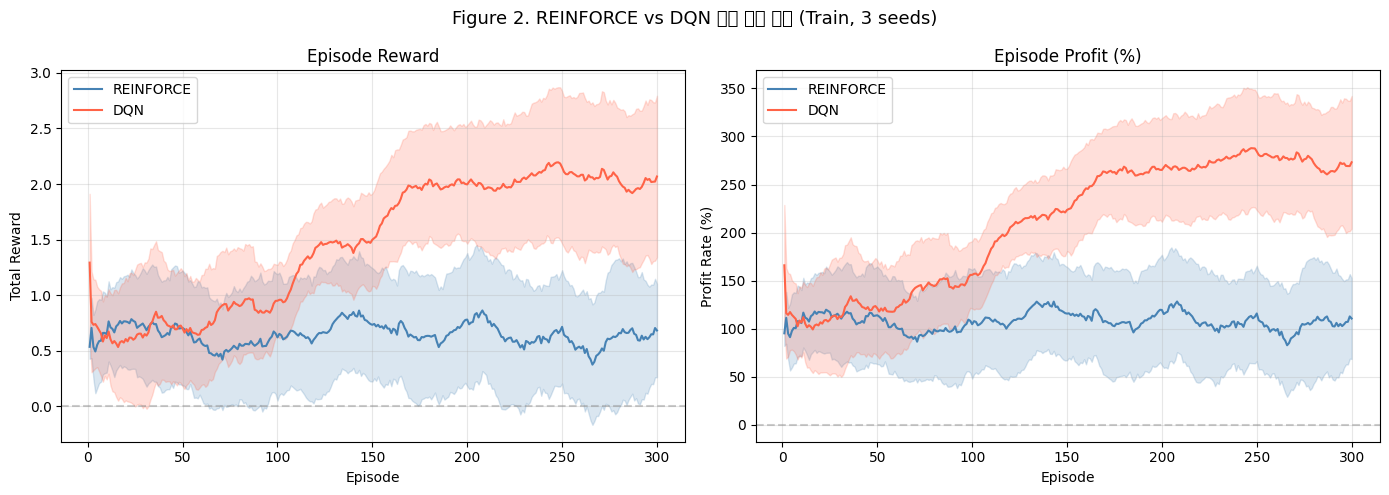

In [11]:
# 학습 곡선 비교
eps_x = np.arange(1, N_EPISODES + 1)
rf_r_mean, rf_r_std = get_mean_std(reinforce_results, 1), get_mean_std(reinforce_results, 1)[1]
rf_p_mean, rf_p_std = get_mean_std(reinforce_results, 2)
dqn_r_mean, dqn_r_std = get_mean_std(dqn_results, 1)
dqn_p_mean, dqn_p_std = get_mean_std(dqn_results, 2)
rf_r_mean = get_mean_std(reinforce_results, 1)[0]
rf_r_std  = get_mean_std(reinforce_results, 1)[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 2. REINFORCE vs DQN 학습 곡선 비교 (Train, 3 seeds)', fontsize=13)

for ax, r_mean, r_std, d_mean, d_std, title, ylabel in [
    (axes[0], rf_r_mean, rf_r_std, dqn_r_mean, dqn_r_std, 'Episode Reward', 'Total Reward'),
    (axes[1], rf_p_mean*100, rf_p_std*100, dqn_p_mean*100, dqn_p_std*100, 'Episode Profit (%)', 'Profit Rate (%)'),
]:
    ax.plot(eps_x, smooth(r_mean), color='steelblue', label='REINFORCE')
    ax.fill_between(eps_x, smooth(r_mean - r_std), smooth(r_mean + r_std), alpha=0.2, color='steelblue')
    ax.plot(eps_x, smooth(d_mean), color='tomato', label='DQN')
    ax.fill_between(eps_x, smooth(d_mean - d_std), smooth(d_mean + d_std), alpha=0.2, color='tomato')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
    ax.set_title(title); ax.set_xlabel('Episode'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig2_learning_curves.png', dpi=150)
plt.show()

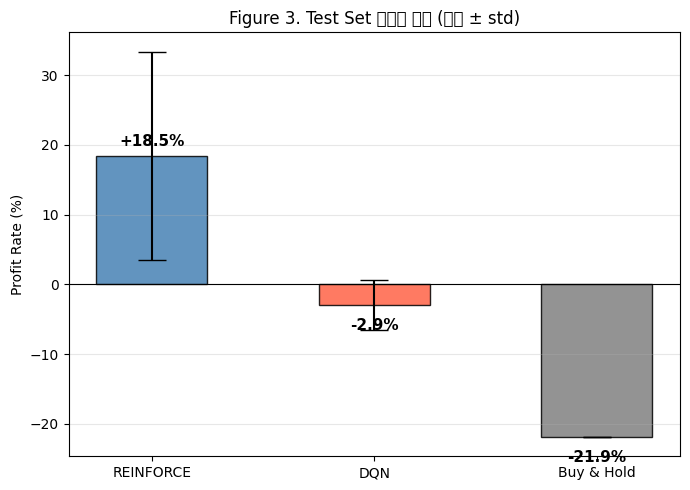

In [12]:
#Test 수익률 Bar Chart
labels = ['REINFORCE', 'DQN', 'Buy & Hold']
means  = [np.mean(rf_test_profits)*100, np.mean(dqn_test_profits)*100, bnh*100]
stds   = [np.std(rf_test_profits)*100,  np.std(dqn_test_profits)*100,  0]
colors = ['steelblue', 'tomato', 'gray']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, means, yerr=stds, capsize=10,
              color=colors, alpha=0.85, edgecolor='black', width=0.5)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (1 if m >= 0 else -4),
            f'{m:+.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Figure 3. Test Set 수익률 비교 (평균 ± std)', fontsize=12)
ax.set_ylabel('Profit Rate (%)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig3_test_bar.png', dpi=150)
plt.show()

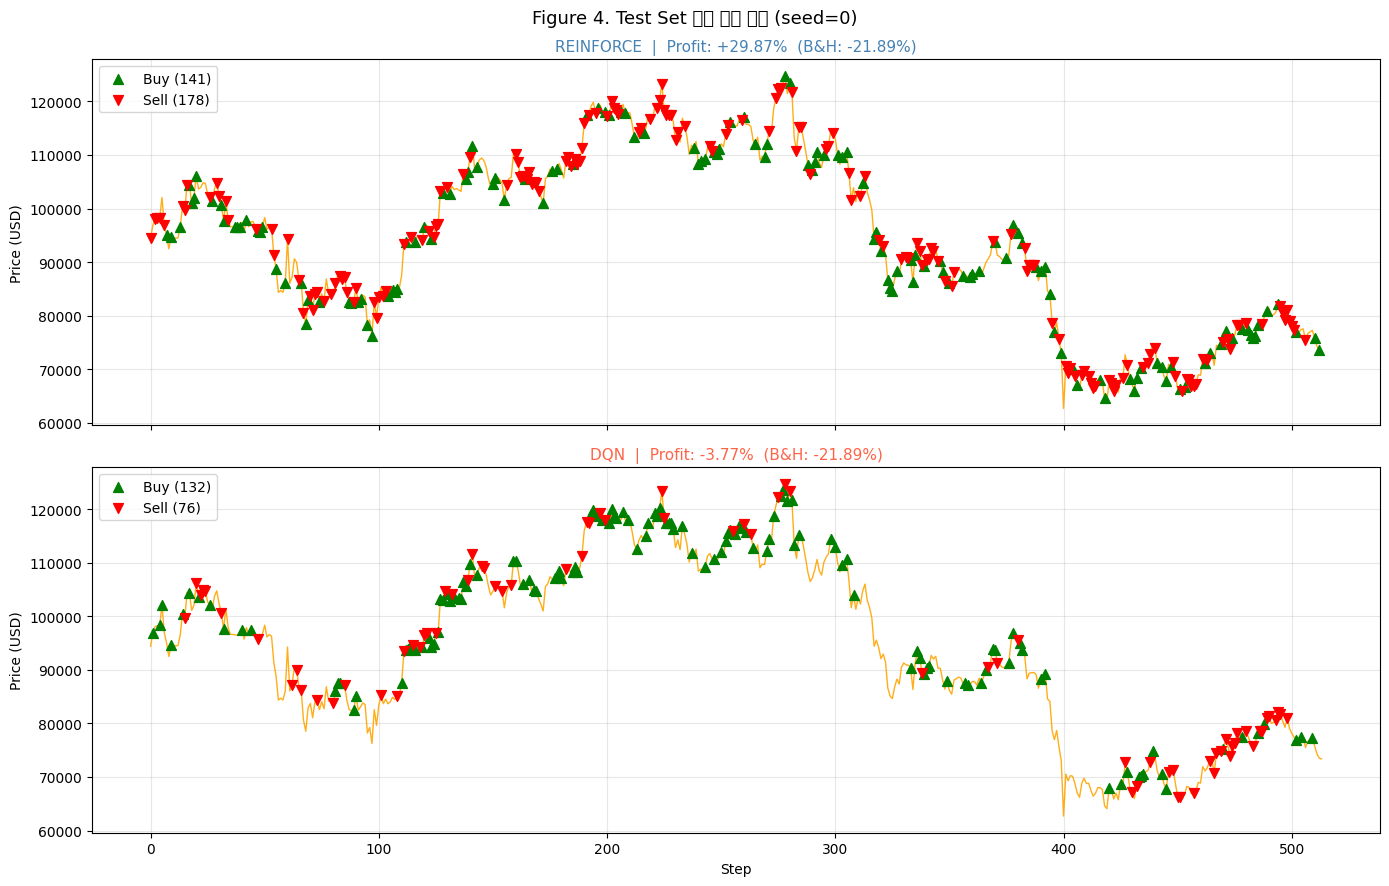

In [13]:
#거래 패턴 비교
rf_p0, bnh, _, rf_acts, rf_prices = evaluate_reinforce(SAVE_DIR+'reinforce_seed0.pth', df_test, 0)
dqn_p0, _,  _, dq_acts, dq_prices = evaluate_dqn(SAVE_DIR+'dqn_seed0.pth', df_test, 0)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Figure 4. Test Set 거래 패턴 비교 (seed=0)', fontsize=13)

for ax, acts, prices, label, color, profit in [
    (axes[0], rf_acts, rf_prices, 'REINFORCE', 'steelblue', rf_p0),
    (axes[1], dq_acts, dq_prices, 'DQN',       'tomato',    dqn_p0)
]:
    pa, aa = np.array(prices), np.array(acts)
    ax.plot(pa, color='orange', linewidth=1, alpha=0.9)
    ax.scatter(np.where(aa==1)[0], pa[aa==1], marker='^', color='green',
               s=50, label=f'Buy ({(aa==1).sum()})', zorder=5)
    ax.scatter(np.where(aa==2)[0], pa[aa==2], marker='v', color='red',
               s=50, label=f'Sell ({(aa==2).sum()})', zorder=5)
    ax.set_title(f'{label}  |  Profit: {profit*100:+.2f}%  (B&H: {bnh*100:+.2f}%)',
                 color=color, fontsize=11)
    ax.set_ylabel('Price (USD)')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

axes[1].set_xlabel('Step')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig4_trade_patterns.png', dpi=150)
plt.show()

# **Hyperparameter 실험**
DQN의 학습률(lr)을 3가지로 변경하여 민감도를 분석

DQN lr=0.0001 학습 중...
  [Seed 0] Ep  200 | Reward:  1.6716 | Profit: 224.55% | ε: 0.050
DQN lr=0.001 학습 중...
  [Seed 0] Ep  200 | Reward:  1.6564 | Profit: 227.81% | ε: 0.050
DQN lr=0.005 학습 중...
  [Seed 0] Ep  200 | Reward: -0.2794 | Profit:  74.74% | ε: 0.050


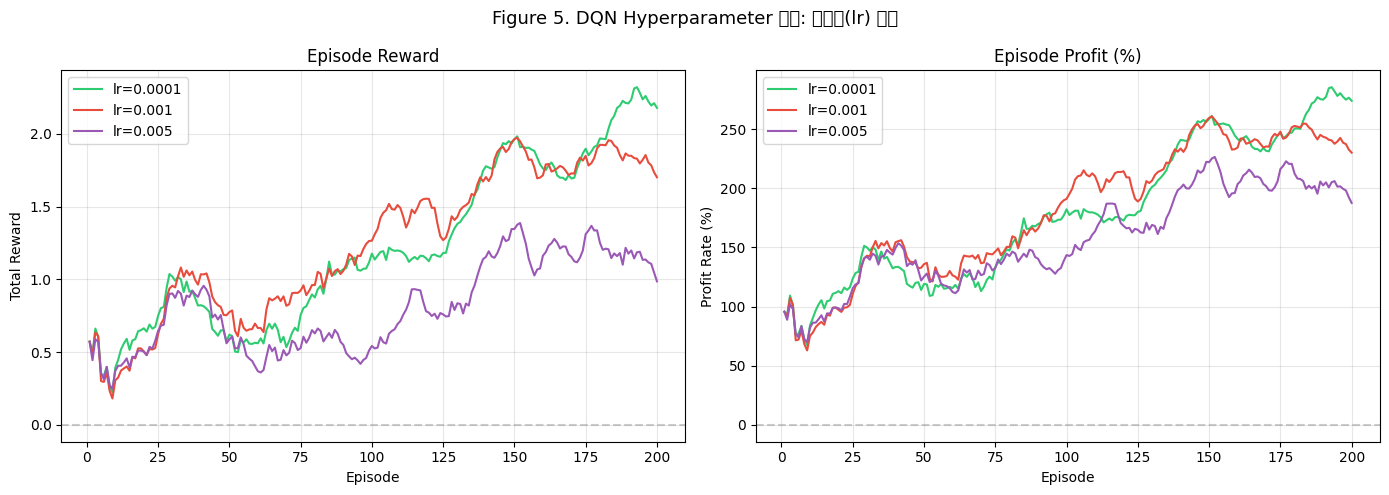

In [16]:
LR_LIST    = [1e-4, 1e-3, 5e-3]
lr_results = {}

for lr in LR_LIST:
    print(f'DQN lr={lr} 학습 중...')
    _, rewards, profits, _, _ = train_dqn(
        df_train, n_episodes=200, lr=lr, seed=0, verbose_interval=200)
    lr_results[lr] = (rewards, profits)

# Hyperparameter 실험
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 5. DQN Hyperparameter 실험: 학습률(lr) 비교', fontsize=13)
palette = ['#2ecc71', '#e74c3c', '#9b59b6']

for (lr, (rewards, profits)), color in zip(lr_results.items(), palette):
    x = np.arange(1, len(rewards)+1)
    axes[0].plot(x, smooth(rewards),             color=color, label=f'lr={lr}')
    axes[1].plot(x, smooth(np.array(profits)*100), color=color, label=f'lr={lr}')

for ax, title, ylabel in [
    (axes[0], 'Episode Reward', 'Total Reward'),
    (axes[1], 'Episode Profit (%)', 'Profit Rate (%)')
]:
    ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
    ax.set_title(title); ax.set_xlabel('Episode'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig5_lr_comparison.png', dpi=150)
plt.show()

# **최종 결과 요약 및 저장**

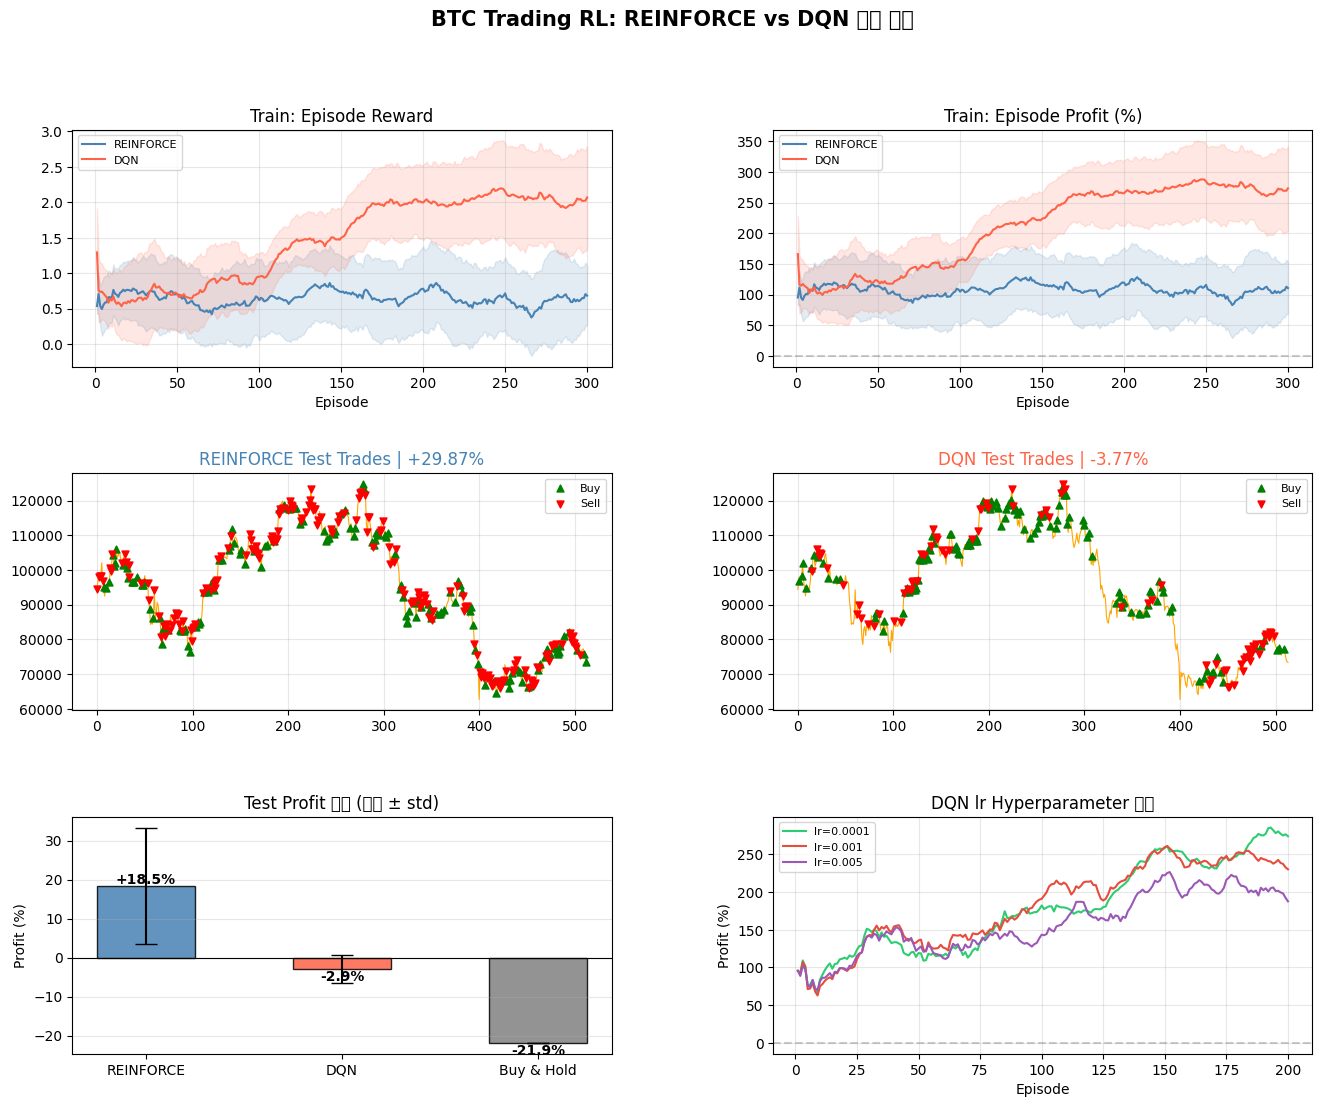

대시보드 저장 완료!


In [17]:
#종합 대시보드
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)
fig.suptitle('BTC Trading RL: REINFORCE vs DQN 종합 결과', fontsize=15, fontweight='bold')

# (0,0) 학습 Reward 곡선
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(eps_x, smooth(rf_r_mean), color='steelblue', label='REINFORCE')
ax1.fill_between(eps_x, smooth(rf_r_mean-rf_r_std), smooth(rf_r_mean+rf_r_std), alpha=0.15, color='steelblue')
ax1.plot(eps_x, smooth(dqn_r_mean), color='tomato', label='DQN')
ax1.fill_between(eps_x, smooth(dqn_r_mean-dqn_r_std), smooth(dqn_r_mean+dqn_r_std), alpha=0.15, color='tomato')
ax1.set_title('Train: Episode Reward'); ax1.set_xlabel('Episode'); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# (0,1) 학습 Profit 곡선
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(eps_x, smooth(rf_p_mean*100), color='steelblue', label='REINFORCE')
ax2.fill_between(eps_x, smooth((rf_p_mean-rf_p_std)*100), smooth((rf_p_mean+rf_p_std)*100), alpha=0.15, color='steelblue')
ax2.plot(eps_x, smooth(dqn_p_mean*100), color='tomato', label='DQN')
ax2.fill_between(eps_x, smooth((dqn_p_mean-dqn_p_std)*100), smooth((dqn_p_mean+dqn_p_std)*100), alpha=0.15, color='tomato')
ax2.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax2.set_title('Train: Episode Profit (%)'); ax2.set_xlabel('Episode'); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# (1,0) REINFORCE 거래 패턴
ax3 = fig.add_subplot(gs[1, 0])
pa, aa = np.array(rf_prices), np.array(rf_acts)
ax3.plot(pa, color='orange', linewidth=0.8)
ax3.scatter(np.where(aa==1)[0], pa[aa==1], marker='^', color='green', s=25, label='Buy', zorder=5)
ax3.scatter(np.where(aa==2)[0], pa[aa==2], marker='v', color='red',   s=25, label='Sell', zorder=5)
ax3.set_title(f'REINFORCE Test Trades | {rf_p0*100:+.2f}%', color='steelblue')
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

# (1,1) DQN 거래 패턴
ax4 = fig.add_subplot(gs[1, 1])
pa, aa = np.array(dq_prices), np.array(dq_acts)
ax4.plot(pa, color='orange', linewidth=0.8)
ax4.scatter(np.where(aa==1)[0], pa[aa==1], marker='^', color='green', s=25, label='Buy', zorder=5)
ax4.scatter(np.where(aa==2)[0], pa[aa==2], marker='v', color='red',   s=25, label='Sell', zorder=5)
ax4.set_title(f'DQN Test Trades | {dqn_p0*100:+.2f}%', color='tomato')
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

# (2,0) Test 수익률 Bar
ax5 = fig.add_subplot(gs[2, 0])
bars = ax5.bar(labels, means, yerr=stds, capsize=8, color=colors, alpha=0.85, edgecolor='black', width=0.5)
for bar, m in zip(bars, means):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(0.5 if m>=0 else -3),
             f'{m:+.1f}%', ha='center', fontweight='bold', fontsize=10)
ax5.axhline(0, color='black', linewidth=0.8)
ax5.set_title('Test Profit 비교 (평균 ± std)'); ax5.set_ylabel('Profit (%)'); ax5.grid(axis='y', alpha=0.3)

# (2,1) lr Hyperparameter
ax6 = fig.add_subplot(gs[2, 1])
for (lr, (_, profits)), color in zip(lr_results.items(), palette):
    ax6.plot(np.arange(1,201), smooth(np.array(profits)*100), color=color, label=f'lr={lr}')
ax6.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax6.set_title('DQN lr Hyperparameter 비교'); ax6.set_xlabel('Episode')
ax6.set_ylabel('Profit (%)'); ax6.legend(fontsize=8); ax6.grid(alpha=0.3)

plt.savefig(SAVE_DIR + 'fig6_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('대시보드 저장 완료!')

In [18]:
#수치 요약 테이블
summary = pd.DataFrame({
    'Algorithm'    : ['REINFORCE', 'DQN', 'Buy & Hold'],
    'Test Profit Mean (%)': [
        round(np.mean(rf_test_profits)*100, 2),
        round(np.mean(dqn_test_profits)*100, 2),
        round(bnh*100, 2)
    ],
    'Test Profit Std (%)': [
        round(np.std(rf_test_profits)*100, 2),
        round(np.std(dqn_test_profits)*100, 2),
        0.0
    ],
    'Avg Trades (seed0)': [
        len([a for a in rf_acts if a == 2]),
        len([a for a in dq_acts if a == 2]),
        1
    ]
})
print('\n======= 최종 성능 요약 =======')
print(summary.to_string(index=False))

summary.to_csv(SAVE_DIR + 'final_summary.csv', index=False)
print('\n모든 결과 저장 완료!')
print('\n저장된 파일 목록:')
for f in sorted(os.listdir(SAVE_DIR)):
    print(f'  {f}')


======= 최종 성능 요약 =======
 Algorithm  Test Profit Mean (%)  Test Profit Std (%)  Avg Trades (seed0)
 REINFORCE                 18.46                14.92                 178
       DQN                 -2.92                 3.59                  76
Buy & Hold                -21.89                 0.00                   1

모든 결과 저장 완료!

저장된 파일 목록:
  dqn_seed0.pth
  dqn_seed1.pth
  dqn_seed2.pth
  fig1_data_overview.png
  fig2_learning_curves.png
  fig3_test_bar.png
  fig4_trade_patterns.png
  fig5_lr_comparison.png
  fig6_dashboard.png
  final_summary.csv
  full_experiment.pkl
  reinforce_seed0.pth
  reinforce_seed1.pth
  reinforce_seed2.pth


In [19]:
print('================================================')
print('       전체 실험 완료 체크리스트')
print('================================================')
print('✅ [1] BTC 데이터 수집 및 기술 지표 계산')
print('✅ [2] BTCTradingEnv 구현 (State/Action/Reward)')
print('✅ [3] REINFORCE 구현 (PolicyNetwork + PG Loss)')
print('✅ [4] DQN 구현 (ReplayBuffer + TargetNet + TD)')
print('✅ [5] seed 3개 학습 + 학습 곡선 신뢰구간')
print('✅ [6] Test 수익률 비교 + 거래 패턴 시각화')
print('✅ [7] Hyperparameter (lr) 실험')
print('✅ [8] 종합 대시보드 + 결과 테이블 저장')
print('================================================')
print(f'\n  REINFORCE : {np.mean(rf_test_profits)*100:+.2f}% ± {np.std(rf_test_profits)*100:.2f}%')
print(f'  DQN       : {np.mean(dqn_test_profits)*100:+.2f}% ± {np.std(dqn_test_profits)*100:.2f}%')
print(f'  Buy&Hold  : {bnh*100:+.2f}%')
print('================================================')

       전체 실험 완료 체크리스트
✅ [1] BTC 데이터 수집 및 기술 지표 계산
✅ [2] BTCTradingEnv 구현 (State/Action/Reward)
✅ [3] REINFORCE 구현 (PolicyNetwork + PG Loss)
✅ [4] DQN 구현 (ReplayBuffer + TargetNet + TD)
✅ [5] seed 3개 학습 + 학습 곡선 신뢰구간
✅ [6] Test 수익률 비교 + 거래 패턴 시각화
✅ [7] Hyperparameter (lr) 실험
✅ [8] 종합 대시보드 + 결과 테이블 저장

  REINFORCE : +18.46% ± 14.92%
  DQN       : -2.92% ± 3.59%
  Buy&Hold  : -21.89%
